<a href="https://colab.research.google.com/github/bawamehar/pytorch-practice/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as f
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# we need tensor of 4 dimension to process these 2D images on mnist dataset because we need to keep track of no of image, height, width and color channels
# Conver MNIST image files into tensor of 4D
transform = transforms.ToTensor()

In [4]:
#train data
train_data = datasets.MNIST(root = '/cnn_data', train= True, download= True, transform= transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


In [5]:
#test data
test_data = datasets.MNIST(root = '/cnn_data', train= False, download= True, transform= transform)

In [6]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [7]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [8]:
# create a small batch size for images....lets say 10
train_loader = DataLoader(train_data, batch_size=10, shuffle = True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [9]:
#define our CNN model
#describe convolutional layer and what it is doing (2 CL)
conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)

In [10]:
# grab 1 mnist record - image
for i, (X_train, y_train) in enumerate(train_data):
  break

In [11]:
X_train.shape

torch.Size([1, 28, 28])

In [12]:
x = X_train.view(1, 1, 28, 28)

In [13]:
#Perfrom our first convolution
x = f.relu(conv1(x)) #Rectified linear unit for our Activation fn

In [14]:
# 1 single image, 6 is the filters/feature map, 26x26 is the image
x.shape

torch.Size([1, 6, 26, 26])

In [15]:
#pass thru the pooling layer
x = f.max_pool2d(x, 2, 2) #kernal size 2, stride of 2

In [16]:
x.shape # 26 / 2 = 13

torch.Size([1, 6, 13, 13])

In [17]:
# second convolutional layer
x = f.relu(conv2(x))

In [18]:
x.shape

torch.Size([1, 16, 11, 11])

In [19]:
# second pooling layer
x = f.max_pool2d(x, 2, 2)

In [20]:
x.shape # 11 / 2 = 5.5 but we need to round down, because we cant invent data to round up

torch.Size([1, 16, 5, 5])

In [21]:
((28-2) / 2 - 2) / 2

5.5

In [22]:
#Model class
class convolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 3, 1)
    self.conv2 = nn.Conv2d(6, 16, 3, 1)
    #fully connected layer
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, X):
    X = f.relu(self.conv1(X))
    X = f.max_pool2d(X, 2, 2) # 2x2 kernal and stride 2

    #second pass
    X = f.relu(self.conv2(X))
    X = f.max_pool2d(X, 2, 2) # 2x2 kernal and stride 2

    #Re-view to flatten it out
    X = X.view(-1, 16*5*5) # -1 so that we can vary the batch size

    #fully connected layers
    X = f.relu(self.fc1(X))
    X = f.relu(self.fc2(X))
    X = self.fc3(X)

    return f.log_softmax(X, dim=1)

In [23]:
#create an intance of the model
torch.manual_seed(41)
model = convolutionalNetwork()
model

convolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [24]:
#Loss function optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #smaller the learning rate, longer its gonna take time to train

In [28]:
import time
start_time = time.time()

#create variables to track things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

#for loop of epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0

  #train
  for b,(X_train, y_train) in enumerate(train_loader):
    b+=1 #start batches at 1
    y_pred = model(X_train) # get predicted valies from the training set. Not flattened 2D
    loss = criterion(y_pred, y_train) # how off are we? compare the predictions to correct answers in y_train

    predicted = torch.max(y_pred.data, 1)[1] # add up the number of correct predictions, indexed off the first point
    batch_corr = (predicted ==y_train).sum() # how many we got corect from this batch. true =1, false = 0, sum those up
    trn_corr +=batch_corr #keep track as we along in training

    #update our parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    #print out some results
    if b%600 == 0:
      print(f'Epoch: {i} Batch: {b} Loss: {loss.item()}')

  train_losses.append(loss)
  train_correct.append(trn_corr)

  #test
  with torch.no_grad(): #no gradient so we dont update our wts and biases with test data
    for b,(X_test, y_test) in enumerate (test_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1] #addign up correct pedictions
      tst_corr += (predicted ==y_test).sum()

  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)


current_time = time.time()
total = current_time - start_time
print(f'Training took: {total/60} minutes!')

Epoch: 0 Batch: 600 Loss: 0.01150826457887888
Epoch: 0 Batch: 1200 Loss: 0.16483262181282043
Epoch: 0 Batch: 1800 Loss: 0.4939056932926178
Epoch: 0 Batch: 2400 Loss: 0.22470073401927948
Epoch: 0 Batch: 3000 Loss: 0.5482009649276733
Epoch: 0 Batch: 3600 Loss: 0.0032613701187074184
Epoch: 0 Batch: 4200 Loss: 0.2689889967441559
Epoch: 0 Batch: 4800 Loss: 0.0005814333562739193
Epoch: 0 Batch: 5400 Loss: 0.005964583717286587
Epoch: 0 Batch: 6000 Loss: 0.05188871547579765
Epoch: 1 Batch: 600 Loss: 0.039343953132629395
Epoch: 1 Batch: 1200 Loss: 0.015936901792883873
Epoch: 1 Batch: 1800 Loss: 0.012183857150375843
Epoch: 1 Batch: 2400 Loss: 0.4423716962337494
Epoch: 1 Batch: 3000 Loss: 0.008131425827741623
Epoch: 1 Batch: 3600 Loss: 0.05597805231809616
Epoch: 1 Batch: 4200 Loss: 0.08481750637292862
Epoch: 1 Batch: 4800 Loss: 0.0001326545752817765
Epoch: 1 Batch: 5400 Loss: 0.0004921124782413244
Epoch: 1 Batch: 6000 Loss: 0.0009876824915409088
Epoch: 2 Batch: 600 Loss: 0.03679517284035683
Epoch

In [30]:
train_correct

[tensor(58815), tensor(59159), tensor(59334), tensor(59447), tensor(59545)]

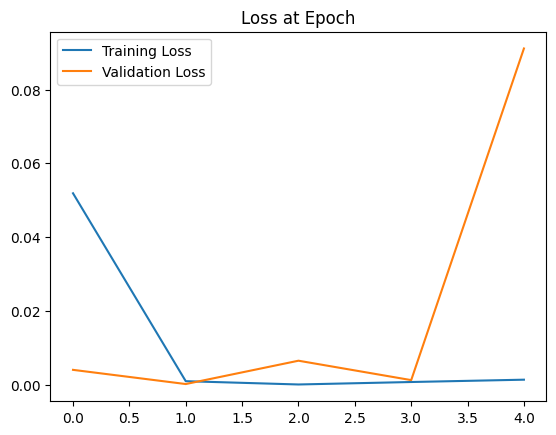

In [31]:
#graph the loss at epoch
train_losses = [t1.item() for t1 in train_losses]
plt.plot(train_losses, label = "Training Loss")
plt.plot(test_losses, label = "Validation Loss")
plt.title("Loss at Epoch")
plt.legend()

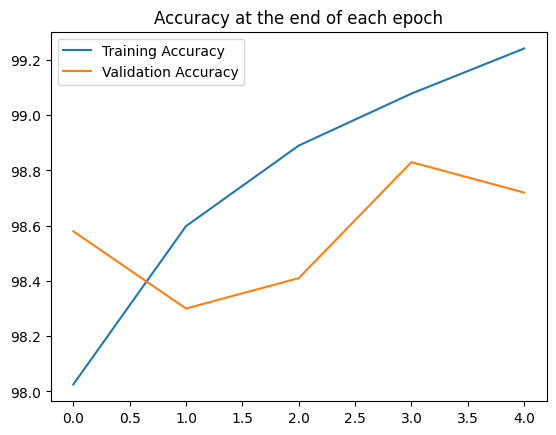

In [37]:
#graph accuracy at the end of each epoch
plt.plot([t/600 for t in train_correct], label="Training Accuracy")
plt.plot([t/100 for t in test_correct], label = "Validation Accuracy")
plt.title("Accuracy at the end of each epoch")
plt.legend()

In [33]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

In [35]:
with torch.no_grad():
  correct = 0
  for X_test, y_test in test_load_everything:
    y_val = model(X_test)
    prediction = torch.max(y_val, 1)[1]
    correct += (prediction == y_test).sum()

In [36]:
correct.item()/len(test_data)*100

98.72

In [38]:
# grab an image
test_data[4143] #tensor with an image in it...at the end, it shows the label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [39]:
#grab the data
test_data[4143][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [40]:
#reshape it
test_data[4143][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

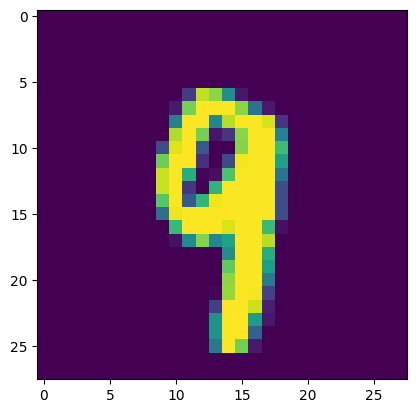

In [41]:
#show the image
plt.imshow(test_data[4143][0].reshape(28,28))

In [42]:
#pass the image thru model
model.eval()
with torch.no_grad():
  new_prediction = model(test_data[4143][0].view(1,1,28,28)) #batch size of 1, 1 color channel, 28x28 image

In [43]:
#check new prediction
new_prediction

tensor([[-2.6822e+01, -2.3283e+01, -2.3134e+01, -2.1553e+01, -1.2198e+01,
         -2.2855e+01, -3.7242e+01, -1.8500e+01, -1.7182e+01, -5.1260e-06]])

In [44]:
new_prediction.argmax()

tensor(9)